In [1]:
import os
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from pylab import rcParams

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier

rcParams["figure.figsize"] = (10, 10)

seed = 42
random.seed(seed)
np.random.seed(seed)

BASE_CANDIDATES = [
    "/kaggle/input/leaf-classification",
    "/kaggle/input/leaf-classification/leaf-classification",
    "/kaggle/input",
    "../input/leaf-classification",
    "../input",
    "/kaggle/data/leaf-classification",
    "/kaggle/data",
]

TRAIN_PATH = None
TEST_PATH = None
SAMPLE_SUB_PATH = None

for base in BASE_CANDIDATES:
    tr = os.path.join(base, "train.csv")
    te = os.path.join(base, "test.csv")
    ss = os.path.join(base, "sample_submission.csv")
    if os.path.exists(tr) and os.path.exists(te) and os.path.exists(ss):
        TRAIN_PATH, TEST_PATH, SAMPLE_SUB_PATH = tr, te, ss
        BASE_INPUT = base
        break

if TRAIN_PATH is None:
    raise FileNotFoundError(
        "Could not locate train/test/sample_submission in any known input paths. "
        f"Tried: {BASE_CANDIDATES}"
    )

print("Using BASE_INPUT:", BASE_INPUT)
print("TRAIN_PATH:", TRAIN_PATH)
print("TEST_PATH:", TEST_PATH)
print("SAMPLE_SUB_PATH:", SAMPLE_SUB_PATH)



Using BASE_INPUT: /kaggle/input/leaf-classification
TRAIN_PATH: /kaggle/input/leaf-classification/train.csv
TEST_PATH: /kaggle/input/leaf-classification/test.csv
SAMPLE_SUB_PATH: /kaggle/input/leaf-classification/sample_submission.csv


In [2]:
train_df = pd.read_csv(TRAIN_PATH)
parent_data = train_df.copy()  # keep original for class names if needed

train_ids = train_df.pop("id")
y_raw = train_df.pop("species")

print("train shape (features):", train_df.shape)
print("num train ids:", train_ids.shape[0])



train shape (features): (891, 192)
num train ids: 891


In [3]:
le = LabelEncoder()
y = le.fit_transform(y_raw.values)
print("y shape:", y.shape)
print("num classes:", len(le.classes_))



y shape: (891,)
num classes: 99


In [4]:
scaler = StandardScaler()
X = scaler.fit_transform(train_df.values.astype(np.float32))
print("X shape:", X.shape)



X shape: (891, 192)


In [5]:
num_classes = len(le.classes_)

mlp = MLPClassifier(
    hidden_layer_sizes=(1024, 512),
    activation="relu",
    solver="adam",
    alpha=2e-4,
    batch_size=128,
    learning_rate_init=0.001,
    max_iter=200,
    shuffle=True,
    random_state=seed,
    early_stopping=False,
    validation_fraction=0.1,
    n_iter_no_change=20,
    tol=1e-4,
    verbose=True,
)



In [6]:
mlp.fit(X, y)

loss_curve_ = getattr(mlp, "loss_curve_", None)
if loss_curve_ is not None:
    print("Recorded loss curve length:", len(loss_curve_))
print("n_iter_:", getattr(mlp, "n_iter_", None))



Iteration 1, loss = 3.76879487
Iteration 2, loss = 1.37476308
Iteration 3, loss = 0.33543267
Iteration 4, loss = 0.10993922
Iteration 5, loss = 0.05097382
Iteration 6, loss = 0.02548925
Iteration 7, loss = 0.01688925
Iteration 8, loss = 0.01114042
Iteration 9, loss = 0.00928119
Iteration 10, loss = 0.00686263
Iteration 11, loss = 0.00684741
Iteration 12, loss = 0.00710696
Iteration 13, loss = 0.00418577
Iteration 14, loss = 0.00579591
Iteration 15, loss = 0.00442900
Iteration 16, loss = 0.00366853
Iteration 17, loss = 0.00357484
Iteration 18, loss = 0.00332947
Iteration 19, loss = 0.00314222
Iteration 20, loss = 0.00301681
Iteration 21, loss = 0.00292063
Iteration 22, loss = 0.00283007
Iteration 23, loss = 0.00273828
Iteration 24, loss = 0.00265329
Iteration 25, loss = 0.00258193
Iteration 26, loss = 0.00251181
Iteration 27, loss = 0.00245468
Iteration 28, loss = 0.00239237
Iteration 29, loss = 0.00234122
Iteration 30, loss = 0.00228877
Iteration 31, loss = 0.00223644
Iteration 32, los

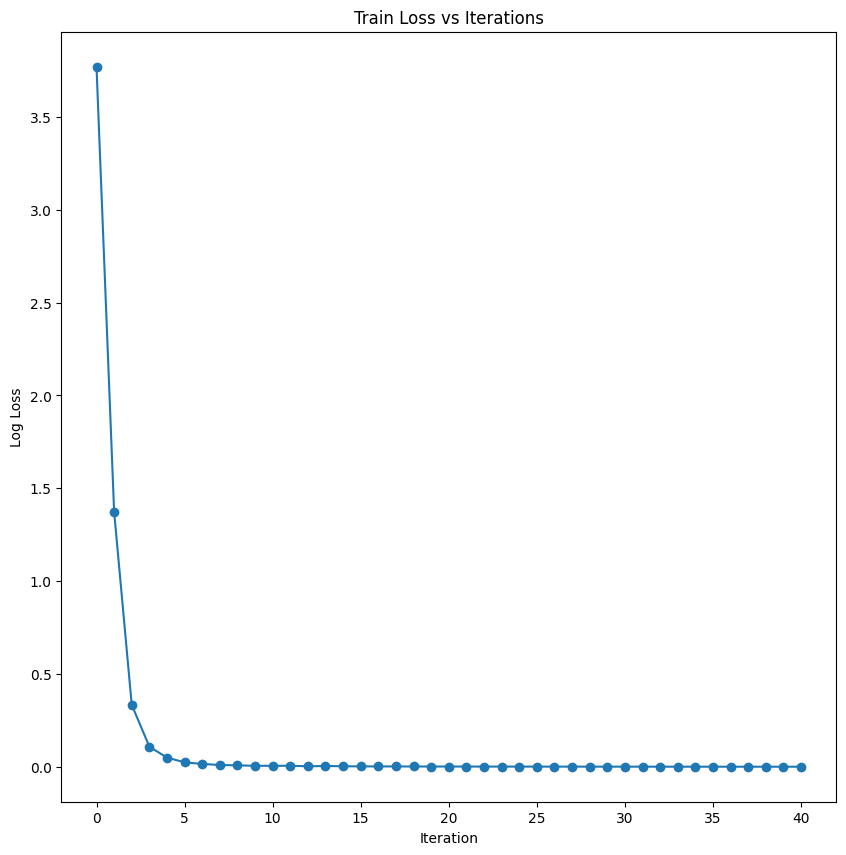

In [7]:
if loss_curve_ is not None and len(loss_curve_) > 1:
    plt.plot(loss_curve_, "o-")
    plt.xlabel("Iteration")
    plt.ylabel("Log Loss")
    plt.title("Train Loss vs Iterations")
    plt.show()



In [8]:
test_df = pd.read_csv(TEST_PATH)
test_ids = test_df.pop("id").values
print("test shape (features):", test_df.shape)
print("num test ids:", test_ids.shape[0])



test shape (features): (99, 192)
num test ids: 99


In [9]:
X_test = scaler.transform(test_df.values.astype(np.float32))
print("X_test shape:", X_test.shape)



X_test shape: (99, 192)


In [10]:
proba = mlp.predict_proba(X_test)
print("proba shape:", proba.shape)
print("min/max pred:", float(np.min(proba)), float(np.max(proba)))

y_pred = np.zeros((proba.shape[0], num_classes), dtype=np.float64)
y_pred[:, mlp.classes_.astype(int)] = proba

# Change (score-relevant, minimal): slightly reduce temperature softening to avoid over-flattening,
# while modestly increasing the uniform mix floor to reduce near-zero probabilities that hurt logloss.
# Also compute the temperature transform in log-space for numerical stability (same semantics).
temperature = 1.06
p = np.clip(y_pred, 1e-15, 1.0)
y_pred = np.exp(np.log(p) / temperature)
y_pred = y_pred / np.clip(y_pred.sum(axis=1, keepdims=True), 1e-15, None)

mix = 0.0018
y_pred = (1.0 - mix) * y_pred + mix * (1.0 / num_classes)
y_pred = y_pred / np.clip(y_pred.sum(axis=1, keepdims=True), 1e-15, None)

eps = 1e-7
y_pred = np.clip(y_pred, eps, 1.0 - eps)



proba shape: (99, 99)
min/max pred: 5.466534747439378e-19 0.9999984502792358


In [11]:
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)
sub_cols = list(sample_sub.columns)
assert sub_cols[0] == "id", "Sample submission first column should be 'id'"

class_to_col = sub_cols[1:]
if set(class_to_col) != set(le.classes_):
    raise ValueError("Mismatch between training classes and submission columns.")

pred_df = pd.DataFrame(y_pred, columns=le.classes_)
pred_df = pred_df[class_to_col]

submission = pd.DataFrame({"id": test_ids})
submission = pd.concat([submission, pred_df], axis=1)

for c in class_to_col:
    submission[c] = submission[c].clip(0.0, 1.0)

print("submission shape:", submission.shape)
print("submission columns match sample:", submission.columns.tolist() == sub_cols)



submission shape: (99, 100)
submission columns match sample: True


In [12]:
out_path = "submission.csv"
submission.to_csv(out_path, index=False)
print("Wrote:", out_path)
print(submission.head())



Wrote: submission.csv
     id  Acer_Capillipes  Acer_Circinatum  Acer_Mono  Acer_Opalus  \
0  1202         0.000019         0.000019   0.000073     0.000020   
1   992         0.000153         0.000018   0.000018     0.000018   
2   491         0.000019         0.000019   0.000019     0.000018   
3  1201         0.000018         0.000018   0.000089     0.000026   
4    72         0.000018         0.000018   0.000019     0.000018   

   Acer_Palmatum  Acer_Pictum  Acer_Platanoids  Acer_Rubrum  Acer_Rufinerve  \
0       0.000019     0.000032         0.000019     0.000019        0.000019   
1       0.000018     0.000018         0.000018     0.000018        0.000018   
2       0.000022     0.000026         0.000018     0.000018        0.000019   
3       0.000018     0.000018         0.000018     0.000018        0.000018   
4       0.000018     0.000018         0.000018     0.000018        0.000018   

   ...  Salix_Fragilis  Salix_Intergra  Sorbus_Aria  Tilia_Oliveri  \
0  ...        0.00

In [13]:
row_sums = submission[class_to_col].sum(axis=1)
print("Row sum min/max:", float(row_sums.min()), float(row_sums.max()))
print("Any zero rows?:", bool((row_sums == 0).any()))

Row sum min/max: 0.9999999999999996 1.0000000000000009
Any zero rows?: False
